# SLM Fine-tuning 

**Steps:**
1. Environment Setup
2. Data Path Configuration
3. Load Data from CSV files 
4. Dataset Preparation
5. Model Training with train loss only
6. Model Evaluation on Test Set
7. Save Trained Model

## 1. Environment Setup

In [7]:
# %pip install torch transformers accelerate sentencepiece pandas scikit-learn tqdm

In [8]:
# --- 1. Environment Setup ---
import os
import sys
import json
import re
import random
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple

# Suppress warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

# Transformers
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# Metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [9]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

## 2. Data Path Configuration

In [10]:
# --- Data Paths Configuration ---
DATA_DIR = r"/kaggle/input/datasets/chinhde/twitter15-16"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")
MODEL_SAVE_PATH = "/kaggle/working/RoBERTaV1"

print(f"Data Directory: {DATA_DIR}")
print(f"Train CSV: {TRAIN_CSV}")
print(f"Test CSV: {TEST_CSV}")
print(f"Model Save Path: {MODEL_SAVE_PATH}")

for fpath, name in [(TRAIN_CSV, 'Train'), (TEST_CSV, 'Test')]:
    if os.path.exists(fpath):
        print(f"{name} file exists: {fpath}")
    else:
        print(f"{name} file not found: {fpath}")

Data Directory: /kaggle/input/datasets/chinhde/twitter15-16
Train CSV: /kaggle/input/datasets/chinhde/twitter15-16/train.csv
Test CSV: /kaggle/input/datasets/chinhde/twitter15-16/test.csv
Model Save Path: /kaggle/working/RoBERTaV1
Train file exists: /kaggle/input/datasets/chinhde/twitter15-16/train.csv
Test file exists: /kaggle/input/datasets/chinhde/twitter15-16/test.csv


## 3. Data Loading from CSV

In [11]:
# --- Shared Preprocessing and Data Loading ---
def preprocess_text(text: str) -> str:
    """
    Shared preprocessing used by both SLM and MRCD.
    - Lowercase
    - Remove URLs
    - Remove @mentions
    - Keep alphanumeric, underscore, # and spaces
    - Normalize spaces
    """
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^\w\s#]", " ", text)
    text = " ".join(text.split())
    return text


def load_data_from_csv(train_csv, test_csv):
   
    def load_csv_file(filepath):
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            return [], []

        try:
            df = pd.read_csv(filepath)
            texts = [preprocess_text(t) for t in df['text'].astype(str).tolist()]
            labels = [0 if label.lower() in ['true', 'non-rumor'] else 1 for label in df['label'].astype(str).tolist()]
            print(f"Loaded {len(texts)} samples from {os.path.basename(filepath)}")
            print(f"  Label distribution: {pd.Series(labels).value_counts().to_dict()}")
            return texts, labels
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return [], []

    print("Loading data from CSV files...")
    train_texts, train_labels = load_csv_file(train_csv)
    test_texts, test_labels = load_csv_file(test_csv)


    print(f"Train size: {len(train_texts)}")
    print(f"Test size: {len(test_texts)}")

    return train_texts, train_labels, test_texts, test_labels
# Load data
train_texts, train_labels, test_texts, test_labels = load_data_from_csv(
    TRAIN_CSV, TEST_CSV
)

Loading data from CSV files...
Loaded 1711 samples from train.csv
  Label distribution: {0: 902, 1: 809}
Loaded 428 samples from test.csv
  Label distribution: {0: 256, 1: 172}
Train size: 1711
Test size: 428


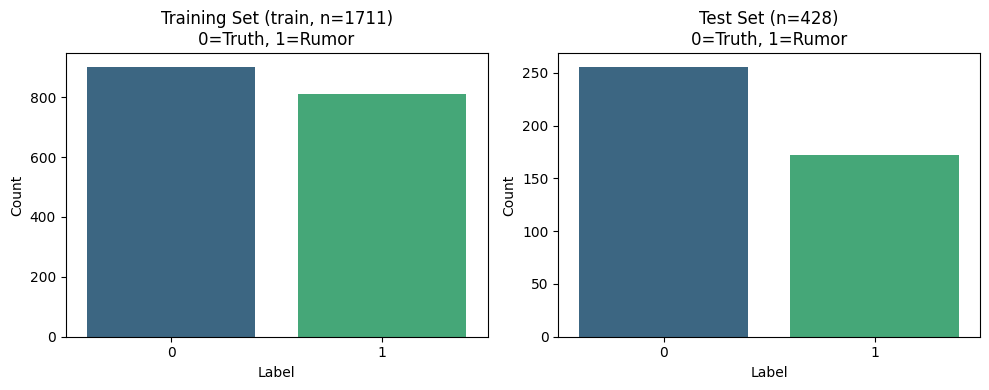

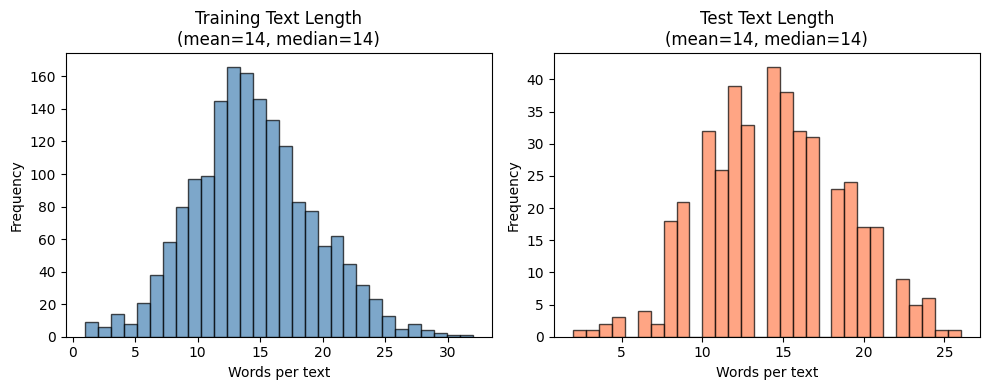

In [12]:
# --- Data Distribution Analysis ---
if len(train_texts) > 0 and len(test_texts) > 0:
    df_train = pd.DataFrame({'label': train_labels})
    df_test = pd.DataFrame({'label': test_labels})

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.countplot(x='label', data=df_train, palette='viridis')
    plt.title(f"Training Set (train, n={len(train_texts)})\n0=Truth, 1=Rumor")
    plt.xlabel("Label")
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    sns.countplot(x='label', data=df_test, palette='viridis')
    plt.title(f"Test Set (n={len(test_texts)})\n0=Truth, 1=Rumor")
    plt.xlabel("Label")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    train_lengths = [len(t.split()) for t in train_texts]
    test_lengths = [len(t.split()) for t in test_texts]

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(train_lengths, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    plt.title(f"Training Text Length\n(mean={np.mean(train_lengths):.0f}, median={np.median(train_lengths):.0f})")
    plt.xlabel("Words per text")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    plt.hist(test_lengths, bins=30, color='coral', alpha=0.7, edgecolor='black')
    plt.title(f"Test Text Length\n(mean={np.mean(test_lengths):.0f}, median={np.median(test_lengths):.0f})")
    plt.xlabel("Words per text")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for visualization")

## 4. Dataset Preparation

In [13]:
# --- Helper Functions ---
class FakeNewsDataset(Dataset):
    """PyTorch Dataset for fake news detection"""
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = preprocess_text(self.texts[idx])
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Loading tokenizer...")
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_dataset = FakeNewsDataset(train_texts, train_labels, tokenizer)
test_dataset = FakeNewsDataset(test_texts, test_labels, tokenizer)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Datasets created:")
print(f"  Train (train: {len(train_dataset)} samples (Batch size: {BATCH_SIZE})")
print(f"  Test: {len(test_dataset)} samples (Batch size: {BATCH_SIZE})")

Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Datasets created:
  Train (train: 1711 samples (Batch size: 32)
  Test: 428 samples (Batch size: 32)


## 5. Model Training

In [14]:
# --- Training Configuration ---
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
EPOCHS = 4
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0

print("Training configuration:")
print(f"  Learning Rate:  {LEARNING_RATE}")
print(f"  Weight Decay:   {WEIGHT_DECAY}")
print(f"  Epochs:         {EPOCHS}")
print(f"  Batch Size:     {BATCH_SIZE}")
print(f"  Warmup Ratio:   {WARMUP_RATIO}")
print("  Max Seq Length: 128")

print("\nLoading RoBERTa-base model...")
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
model.to(device)
print(f"Model loaded on {device}")

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("\nOptimizer & Scheduler:")
print(f"  Total steps:  {total_steps}")
print(f"  Warmup steps: {warmup_steps}")

Training configuration:
  Learning Rate:  1e-05
  Weight Decay:   0.01
  Epochs:         4
  Batch Size:     32
  Warmup Ratio:   0.1
  Max Seq Length: 128

Loading RoBERTa-base model...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on cuda

Optimizer & Scheduler:
  Total steps:  216
  Warmup steps: 21


In [15]:
# Class weights để xử lý mất cân bằng (Truth=256, Rumor=172)
import torch
total_samples = 256 + 172
class_weights = torch.tensor([
    total_samples / (2 * 256),   # Truth
    total_samples / (2 * 172),   # Rumor
], dtype=torch.float).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

print(f"Class weights — Truth: {class_weights[0]:.4f}, Rumor: {class_weights[1]:.4f}")
print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")

Class weights — Truth: 0.8359, Rumor: 1.2442
Total steps: 216 | Warmup: 21


In [16]:
# --- Training Loop ---
def train_slm(model, train_loader, optimizer, scheduler, device, epochs, loss_fn):
    history = {'loss': []}
    best_train_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        total_loss   = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in progress_bar:
            optimizer.zero_grad()
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss    = loss_fn(outputs.logits, labels)   # weighted loss
            total_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_loss = total_loss / len(train_loader)
        history['loss'].append(avg_loss)

        if avg_loss < best_train_loss:
            best_train_loss = avg_loss
            torch.save(model.state_dict(), "best_model.pt")
            print(f"  Train Loss: {avg_loss:.4f} Best saved")
        else:
            print(f"  Train Loss: {avg_loss:.4f} (best: {best_train_loss:.4f})")

    model.load_state_dict(torch.load("best_model.pt"))
    print("\nTraining complete — best model restored.")
    return history


history = train_slm(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=EPOCHS,
    loss_fn=loss_fn,   # truyền weighted loss
)

Epoch 1/4:   0%|          | 0/54 [00:00<?, ?it/s]

  Train Loss: 0.6950 Best saved


Epoch 2/4:   0%|          | 0/54 [00:00<?, ?it/s]

  Train Loss: 0.5887 Best saved


Epoch 3/4:   0%|          | 0/54 [00:00<?, ?it/s]

  Train Loss: 0.4538 Best saved


Epoch 4/4:   0%|          | 0/54 [00:00<?, ?it/s]

  Train Loss: 0.3815 Best saved

Training complete — best model restored.


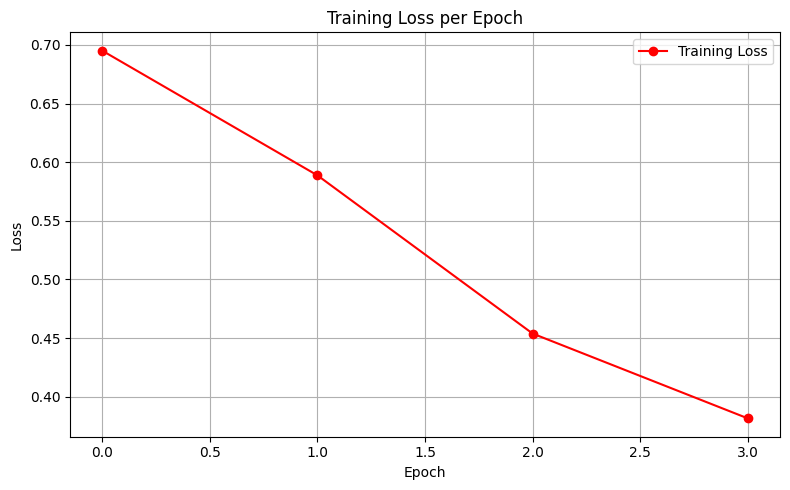

In [17]:
# --- Plot Training History (Train Loss Only) ---
plt.figure(figsize=(8, 5))
plt.plot(history['loss'], label='Training Loss', color='red', marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# --- Test Set Evaluation ---
def evaluate_on_test_set(model, test_loader, device):
    """Evaluate model on test set"""
    model.eval()
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    return labels_all, preds_all

test_labels_true, test_preds = evaluate_on_test_set(model, test_loader, device)

test_acc = accuracy_score(test_labels_true, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels_true, test_preds, average='binary')

print("\nTest Set Evaluation:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels_true, test_preds, target_names=['Truth', 'Rumor'], digits=4))

Testing:   0%|          | 0/14 [00:00<?, ?it/s]


Test Set Evaluation:
  Accuracy:  0.6893
  Precision: 0.6054
  Recall:    0.6512
  F1 Score:  0.6275

Classification Report:
              precision    recall  f1-score   support

       Truth     0.7531    0.7148    0.7335       256
       Rumor     0.6054    0.6512    0.6275       172

    accuracy                         0.6893       428
   macro avg     0.6792    0.6830    0.6805       428
weighted avg     0.6937    0.6893    0.6909       428



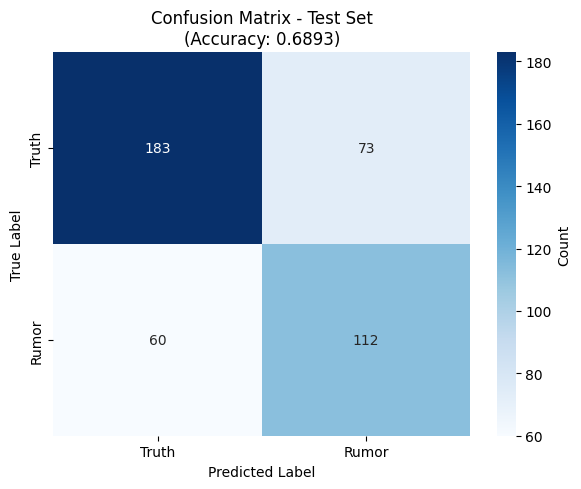

In [19]:
# --- Confusion Matrix ---
cm = confusion_matrix(test_labels_true, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Truth', 'Rumor'],
            yticklabels=['Truth', 'Rumor'],
            cbar_kws={'label': 'Count'})
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title(f'Confusion Matrix - Test Set\n(Accuracy: {test_acc:.4f})')
plt.tight_layout()
plt.show()

In [20]:
# --- Save Model and Tokenizer ---
print("Saving trained model and tokenizer...")
print(f"  Path: {MODEL_SAVE_PATH}")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

metadata = {
    "model_name": "roberta-base",
    "num_labels": 2,
    "labels_mapping": {"0": "truth", "1": "rumor"},
    "training_epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "test_accuracy": float(test_acc),
    "test_precision": float(precision),
    "test_recall": float(recall),
    "test_f1": float(f1),
    "training_samples": len(train_dataset),
    "test_samples": len(test_dataset)
}

with open(os.path.join(MODEL_SAVE_PATH, "training_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("Model saved successfully")
print("\nSaved files:")
for file in os.listdir(MODEL_SAVE_PATH):
    file_path = os.path.join(MODEL_SAVE_PATH, file)
    file_size = os.path.getsize(file_path) / (1024 * 1024)
    print(f"  - {file} ({file_size:.2f} MB)")

print("\nTraining summary:")
print(json.dumps(metadata, indent=2))

Saving trained model and tokenizer...
  Path: /kaggle/working/RoBERTaV1


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully

Saved files:
  - training_metadata.json (0.00 MB)
  - tokenizer.json (3.39 MB)
  - config.json (0.00 MB)
  - model.safetensors (475.51 MB)
  - tokenizer_config.json (0.00 MB)

Training summary:
{
  "model_name": "roberta-base",
  "num_labels": 2,
  "labels_mapping": {
    "0": "truth",
    "1": "rumor"
  },
  "training_epochs": 4,
  "batch_size": 32,
  "learning_rate": 1e-05,
  "weight_decay": 0.01,
  "test_accuracy": 0.6892523364485982,
  "test_precision": 0.6054054054054054,
  "test_recall": 0.6511627906976745,
  "test_f1": 0.6274509803921569,
  "training_samples": 1711,
  "test_samples": 428
}
